In [ ]:
!pip install qiskit qiskit_aer numpy scipy pylatexenc qiskit-algorithms qiskit-nature qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━

ISING MODEL

$$\hat{H} = -J \sum_{i=1}^{N} \hat{\sigma}_i^z \hat{\sigma}_{i+1}^z - g \sum_{i=1}^{N} \hat{\sigma}_i^x$$

In [ ]:
import qiskit

In [ ]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import state_fidelity

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA,POWELL
from qiskit.primitives import StatevectorEstimator as Estimator

In [ ]:
def ising(n,j,g):
    pauli_list=[]
    for _ in range(n):
        pauli_str=['I']*n
        pauli_str[_]='Z'
        pauli_str[(_+1)%n]='Z'
        pauli_list.append((''.join(pauli_str),-j))

    for _ in range(n):
        pauli_str=['I']*n
        pauli_str[_]='X'
        pauli_list.append((''.join(pauli_str),-g))

    return SparsePauliOp.from_list(pauli_list)


In [ ]:
hamiltonian=ising(4,1.0,1.0)
print(hamiltonian)


SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'ZIIZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],
              coeffs=[-1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j])


In [ ]:
hamiltonian_matrix = hamiltonian.to_matrix()
# eigh returns both eigenvalues (w) and corresponding eigenvectors (v)
exact_energies, exact_eigenvectors = np.linalg.eigh(hamiltonian_matrix)

exact_ground_energy = exact_energies[0]
exact_ground_statevector = exact_eigenvectors[:, 0]

In [ ]:
n=4
ansatz = TwoLocal(
        n,
        rotation_blocks=['ry'],
        entanglement_blocks='cx',
        entanglement='linear',
        reps=2,
        insert_barriers=True
    )

/tmp/ipykernel_1991/3212006094.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(


In [ ]:
print(f"Total number of parameters: {ansatz.num_parameters}")

Total number of parameters: 12


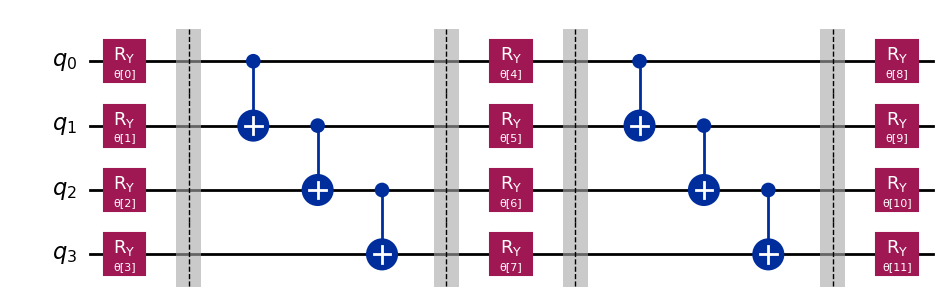

In [ ]:
ansatz.decompose().draw('mpl')

In [ ]:
counts = []
values = []

def convergence_callback(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)

estimator = Estimator()
optimizer = POWELL(maxiter=100)

vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
        callback=convergence_callback
    )

In [ ]:
result=vqe.compute_minimum_eigenvalue(hamiltonian)
vqe_energy = result.eigenvalue.real
print(f"VQE Estimated Energy:      {vqe_energy:.6f}")

VQE Estimated Energy:      -5.110754


<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1991/2737711085.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Energy expectation value $\langle H \\rangle$', fontsize=12)


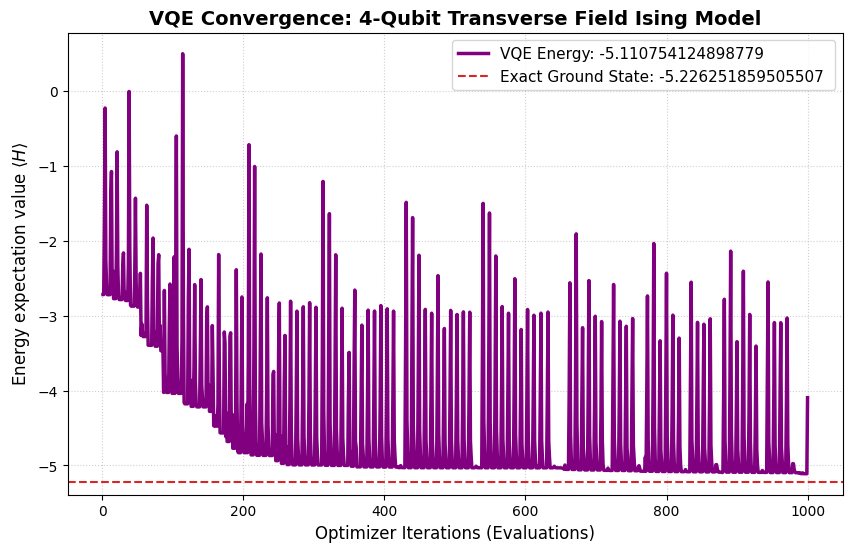

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(counts, values, label=f'VQE Energy: {vqe_energy}', color='purple', lw=2.5)
plt.axhline(y=exact_ground_energy, color='#d62728', linestyle='--', label=f'Exact Ground State: {exact_ground_energy} ')
plt.xlabel('Optimizer Iterations (Evaluations)', fontsize=12)
plt.ylabel('Energy expectation value $\langle H \\rangle$', fontsize=12)
plt.title(f'VQE Convergence: {n}-Qubit Transverse Field Ising Model', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:


optimized_circuit = ansatz.assign_parameters(result.optimal_parameters)

# Build a Qiskit Statevector wrapper out of the optimized circuit layout
vqe_statevector = Statevector.from_instruction(optimized_circuit)

# Calculate the squared overlap between the exact vector and our VQE vector
fidelity = state_fidelity(exact_ground_statevector, vqe_statevector)

print(f"Quantum State Fidelity (F): {fidelity:.6f}")
print(f"Percentage State Overlap:   {fidelity * 100:.2f}%")

Quantum State Fidelity (F): 0.862085
Percentage State Overlap:   86.21%


ADDING NOISE TO OUR ISING SPIN CHAIN MODEL


In [ ]:
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

HEISENBERG XY
$$H = -J \sum_{i=0}^{3} (X_i X_{i+1} + Y_i Y_{i+1}) - h \sum_{i=0}^{3} Z_i$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorEstimator as Estimator

In [ ]:
def heisenberg_xy(n,j,h):

    pauli_list=[]
    coeffs=[]

    for i in range(n):
        pauli_str=['I']*n
        pauli_str[i]='X'
        pauli_str[(i+1)%n]='X'
        pauli_list.append(''.join(pauli_str))
        coeffs.append(-j)

        pauli_str_y = ['I'] * n
        pauli_str_y[i] = 'Y'
        pauli_str_y[(i+1)%n] = 'Y'
        pauli_list.append("".join(pauli_str_y))
        coeffs.append(-j)

    for i in range(n):
        pauli_str=['I']*n
        pauli_str[i]='Z'
        pauli_list.append(''.join(pauli_str))
        coeffs.append(-h)




    return SparsePauliOp.from_list(list(zip(pauli_list,coeffs)))

In [ ]:
hamiltonian=heisenberg_xy(4,1.0,1.0)

In [ ]:
print(hamiltonian)

SparsePauliOp(['XXII', 'YYII', 'IXXI', 'IYYI', 'IIXX', 'IIYY', 'XIIX', 'YIIY', 'ZIII', 'IZII', 'IIZI', 'IIIZ'],
              coeffs=[-1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j,
 -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j])


In [ ]:
hamiltonian.to_matrix()

array([[-4.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j, -2.+0.j, -2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j, -2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j, -2.+0.j, -2.+0.j,  0.+0.j, -2.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -2.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j, -2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, -2.+0.j,  0.+0.j, -2.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j, -2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -2.+0.j,  0.+0.j,  0.+0.j, -2.+0.j,
         0.+0.j,  0.+0.j, -2.+0.j,  0.+0.j,  0.+0.j, -2.+0.j,  0.+0.j,
         0.+0

In [ ]:
n=4
ansatz=TwoLocal(
    n,
    rotation_blocks=['ry'],
    entanglement_blocks='cx',
    entanglement='linear',
    reps=3,
    insert_barriers=True
)

/tmp/ipykernel_1991/1498808913.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz=TwoLocal(


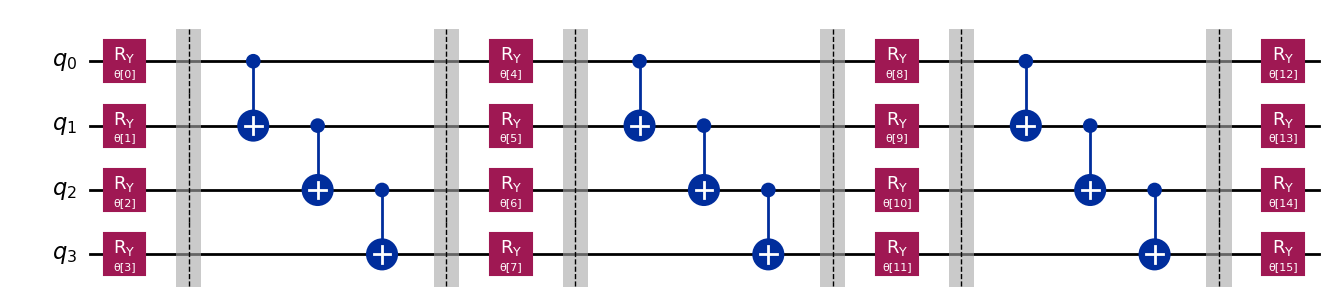

In [ ]:
ansatz.decompose().draw('mpl')

In [ ]:
counts=[]
values=[]
def callback(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)

In [ ]:
estimator=Estimator()
optimizer=COBYLA(maxiter=150)
vqe=VQE(estimator=estimator,ansatz=ansatz,optimizer=optimizer,
        callback=callback
        )

In [ ]:
result=vqe.compute_minimum_eigenvalue(hamiltonian)

In [ ]:
print(result)

{   'aux_operators_evaluated': None,
    'cost_function_evals': 150,
    'eigenvalue': np.float64(-5.566751203832243),
    'optimal_circuit': <qiskit.circuit.library.n_local.two_local.TwoLocal object at 0x7c02ef101e50>,
    'optimal_parameters': {   ParameterVectorElement(θ[13]): np.float64(-5.603263453954563),
                              ParameterVectorElement(θ[12]): np.float64(2.6042082041029944),
                              ParameterVectorElement(θ[14]): np.float64(1.4703726926583243),
                              ParameterVectorElement(θ[15]): np.float64(0.4309459146550937),
                              ParameterVectorElement(θ[0]): np.float64(2.9954523185283457),
                              ParameterVectorElement(θ[7]): np.float64(-5.8587188655470905),
                              ParameterVectorElement(θ[11]): np.float64(6.327204410828406),
                              ParameterVectorElement(θ[4]): np.float64(2.3314982947246254),
                              Parameter

In [ ]:
'''
exact eigenvalues
'''
exact_energies,eigen_vector=np.linalg.eigh(hamiltonian.to_matrix())
print(exact_energies)


[-6.00000000e+00 -5.65685425e+00 -4.00000000e+00 -2.00000000e+00
 -2.00000000e+00 -2.00000000e+00 -3.33066902e-16  5.01301089e-46
  7.99561325e-17  8.88178420e-16  2.00000000e+00  2.00000000e+00
  2.00000000e+00  4.00000000e+00  5.65685425e+00  6.00000000e+00]


In [ ]:
minimum_energy=min(exact_energies)
print(f'Exact ground state energy:{minimum_energy}')

Exact ground state energy:-6.0


<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1991/3573034155.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Energy expectation value $\langle H \\rangle$',fontsize=12)


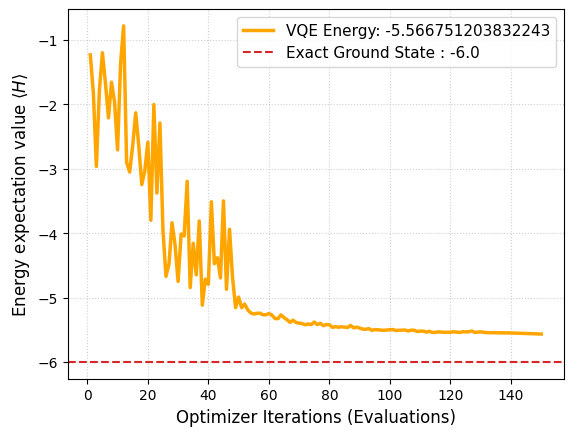

In [ ]:
plt.figsize=(10,6)
plt.plot(counts,values,'-',label='VQE Energy: -5.566751203832243',color='orange',lw=2.5)
plt.axhline(y=minimum_energy,color='#d62728',linestyle='--',label='Exact Ground State : -6.0')
plt.xlabel('Optimizer Iterations (Evaluations)',fontsize=12)
plt.ylabel('Energy expectation value $\langle H \\rangle$',fontsize=12)
plt.legend(fontsize=11,loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
actial_wavefunction=eigen_vector[:,0]

In [ ]:
circuit=ansatz.assign_parameters(result.optimal_parameters)
trial_wavefunction=Statevector.from_instruction(circuit)
fidelity=state_fidelity(actial_wavefunction,trial_wavefunction)
print(f"Quantum State Fidelity (F): {fidelity:.6f}")
print(f"Percentage State Overlap:   {fidelity * 100:.2f}%")


Quantum State Fidelity (F): 0.627174
Percentage State Overlap:   62.72%


HEISENBERG XYZ

$$H = -\sum_{i=0}^{3} (J_x X_i X_{i+1} + J_y Y_i Y_{i+1} + J_z Z_i Z_{i+1}) - h \sum_{i=0}^{3} Z_i$$

In [ ]:


def heisenberg_xyz(n,jx,jy,jz,h):

    pauli_list=[]
    for i in range(n):
        pauli_str=['I']*n
        pauli_str[i]='X'
        pauli_str[(i+1)%n]='X'
        pauli_list.append((''.join(pauli_str),-jx))

        pauli_str=['I']*n
        pauli_str[i]='Y'
        pauli_str[(i+1)%n]='Y'
        pauli_list.append((''.join(pauli_str),-jy))


        pauli_str=['I']*n
        pauli_str[i]='Z'
        pauli_str[(i+1)%n]='Z'
        pauli_list.append((''.join(pauli_str),-jz))

    for i in range(n):
        pauli_str=['I']*n
        pauli_str[i]='Z'
        pauli_list.append((''.join(pauli_str),-h))


    return SparsePauliOp.from_list(pauli_list)




In [ ]:
hamiltonian=heisenberg_xyz(4,1.0,0.7,0.5,0.3)
print(hamiltonian)
print(hamiltonian.to_matrix())

SparsePauliOp(['XXII', 'YYII', 'ZZII', 'IXXI', 'IYYI', 'IZZI', 'IIXX', 'IIYY', 'IIZZ', 'XIIX', 'YIIY', 'ZIIZ', 'ZIII', 'IZII', 'IIZI', 'IIIZ'],
              coeffs=[-1. +0.j, -0.7+0.j, -0.5+0.j, -1. +0.j, -0.7+0.j, -0.5+0.j, -1. +0.j,
 -0.7+0.j, -0.5+0.j, -1. +0.j, -0.7+0.j, -0.5+0.j, -0.3+0.j, -0.3+0.j,
 -0.3+0.j, -0.3+0.j])
[[-3.2+0.j  0. +0.j  0. +0.j -0.3+0.j  0. +0.j  0. +0.j -0.3+0.j  0. +0.j
   0. +0.j -0.3+0.j  0. +0.j  0. +0.j -0.3+0.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j -0.6+0.j -1.7+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -0.3+0.j
  -1.7+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -0.3+0.j  0. +0.j  0. +0.j]
 [ 0. +0.j -1.7+0.j -0.6+0.j  0. +0.j -1.7+0.j  0. +0.j  0. +0.j  0. +0.j
   0. +0.j  0. +0.j  0. +0.j -0.3+0.j  0. +0.j  0. +0.j -0.3+0.j  0. +0.j]
 [-0.3+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -1.7+0.j  0. +0.j  0. +0.j
   0. +0.j  0. +0.j -1.7+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -0.3+0.j]
 [ 0. +0.j  0. +0.j -1.7+0.j  0. +0.j -0.6+0.j  0. +0.j  0. +0.j -0.3+0.j
 

In [ ]:
ansatz=TwoLocal(
    n,
    rotation_blocks=['ry','rx'],
    entanglement_blocks='cz',
    entanglement='full',
    reps=3,
    insert_barriers=True
)


/tmp/ipykernel_1991/3464137264.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz=TwoLocal(


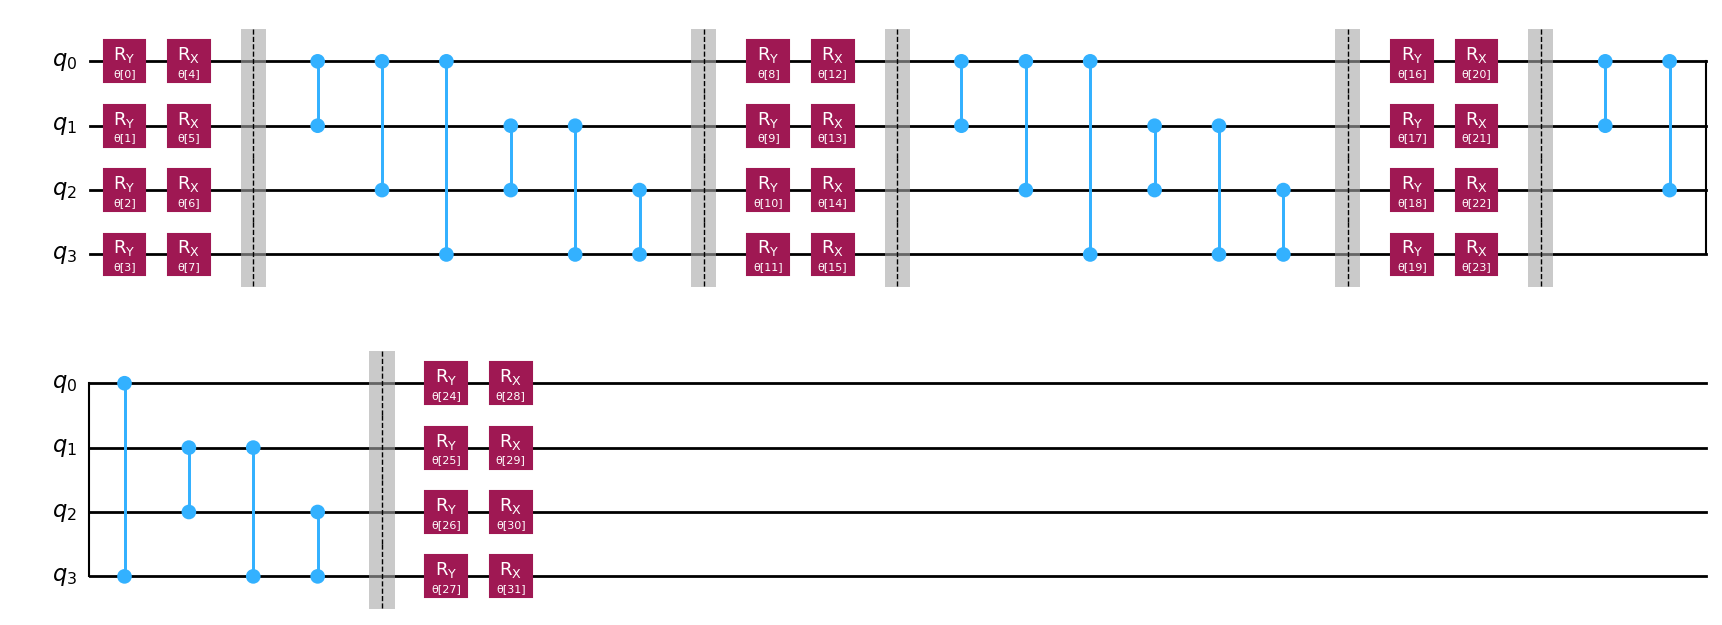

In [ ]:
ansatz.decompose().draw('mpl')

In [ ]:
estimator=Estimator()
optimizer=COBYLA(maxiter=300)

In [ ]:
counts=[]
values=[]

def callback(eval_count, parameters, mean, std):

    counts.append(eval_count)
    values.append(mean)


In [ ]:
vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback

)

In [ ]:
result=vqe.compute_minimum_eigenvalue(hamiltonian)
print(result)

{   'aux_operators_evaluated': None,
    'cost_function_evals': 300,
    'eigenvalue': np.float64(-4.158431079835325),
    'optimal_circuit': <qiskit.circuit.library.n_local.two_local.TwoLocal object at 0x7c02edad1ee0>,
    'optimal_parameters': {   ParameterVectorElement(θ[8]): np.float64(2.713117069191016),
                              ParameterVectorElement(θ[13]): np.float64(-2.915630584674299),
                              ParameterVectorElement(θ[10]): np.float64(4.870847314142123),
                              ParameterVectorElement(θ[16]): np.float64(1.5809199599324124),
                              ParameterVectorElement(θ[6]): np.float64(-4.061086158533949),
                              ParameterVectorElement(θ[14]): np.float64(2.5277155234705266),
                              ParameterVectorElement(θ[9]): np.float64(3.280664432930278),
                              ParameterVectorElement(θ[1]): np.float64(2.906309905674919),
                              ParameterVecto

In [ ]:
'''
exact values'''

exactvalue=min(np.linalg.eigvalsh(hamiltonian.to_matrix()))
print(exactvalue)

-4.248528137423858


In [ ]:
eigenvalue,eigenvector=np.linalg.eigh(hamiltonian.to_matrix())
actual_wave=eigenvector[:,0]

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1991/3291575104.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Energy expectation value $\langle H \\rangle$',fontsize=12)


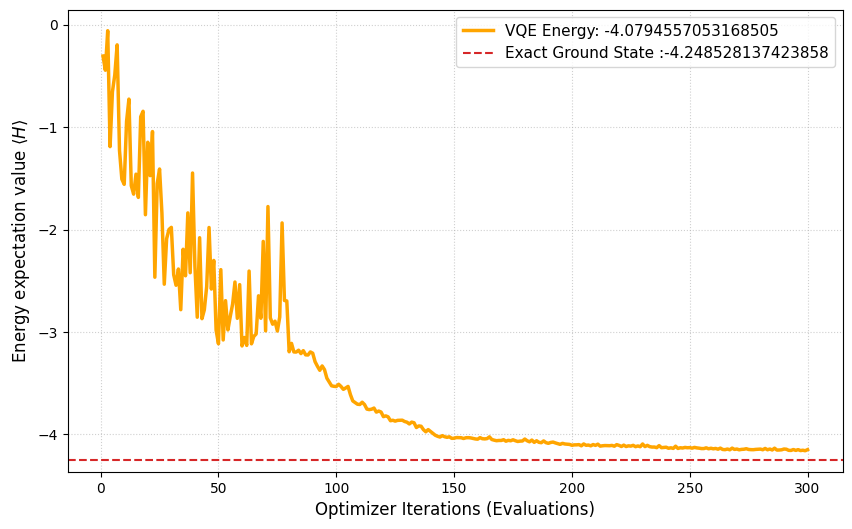

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(counts,values,'-',label='VQE Energy: -4.0794557053168505',color='orange',lw=2.5)
plt.axhline(y=exactvalue,color='#d62728',linestyle='--',label='Exact Ground State :-4.248528137423858')
plt.xlabel('Optimizer Iterations (Evaluations)',fontsize=12)
plt.ylabel('Energy expectation value $\langle H \\rangle$',fontsize=12)
plt.legend(fontsize=11,loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
trial_function=ansatz.assign_parameters(result.optimal_parameters)
trial_state=Statevector.from_instruction(trial_function)
fidelity=state_fidelity(actual_wave,trial_state)
print(f"Quantum State Fidelity (F): {fidelity:.6f}")
print(f"Percentage State Overlap:   {fidelity * 100:.2f}%")


Quantum State Fidelity (F): 0.548002
Percentage State Overlap:   54.80%


HUBBARD MODEL
$$H = -t \sum_{\sigma=\uparrow,\downarrow} (c^\dagger_{0,\sigma}c_{1,\sigma} + c^\dagger_{1,\sigma}c_{0,\sigma}) + U \sum_{i=0}^{1} n_{i,\uparrow}n_{i,\downarrow}$$

In [ ]:
import numpy as np
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper

In [ ]:
t=1.0
U=4.0
pauli_terms=[
    ("XZXI", -t / 2),
    ("YZYI", -t / 2),
    ("IXZX", -t / 2),
    ("IYZY", -t / 2),


    ("IIII", 2 * (U / 4)),
    ("IIIZ", -U / 4),
    ("IIZI", -U / 4),
    ("IZII", -U / 4),
    ("ZIII", -U / 4),
    ("IIZZ",  U / 4),
    ("ZZII",  U / 4),

]

In [ ]:
qubit_hamil=SparsePauliOp.from_list(pauli_terms)
print(qubit_hamil)

SparsePauliOp(['XZXI', 'YZYI', 'IXZX', 'IYZY', 'IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'ZZII'],
              coeffs=[-0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,  2. +0.j, -1. +0.j, -1. +0.j,
 -1. +0.j, -1. +0.j,  1. +0.j,  1. +0.j])


In [ ]:
ansatz=TwoLocal(
    num_qubits=4,
    rotation_blocks=['ry','rz'],
    entanglement_blocks='cx',
    entanglement='linear',
    reps=2
)


/tmp/ipykernel_1991/2328397402.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz=TwoLocal(


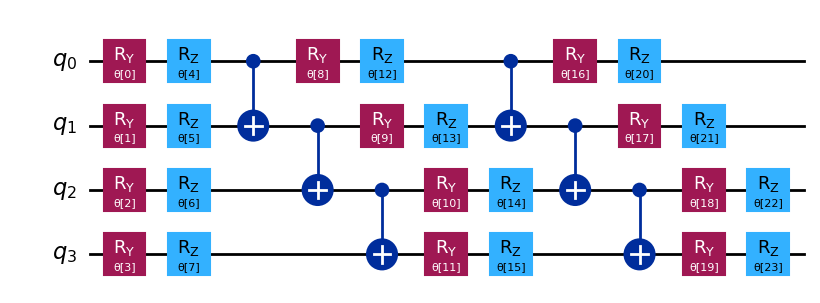

In [ ]:
ansatz.decompose().draw('mpl')

In [ ]:
counts=[]
values=[]

def callback(eval_count, parameters, mean, std):

    counts.append(eval_count)
    values.append(mean)


In [ ]:
optimizer=COBYLA(maxiter=300)
estimator=Estimator()
vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback
)

In [ ]:
RESULT=vqe.compute_minimum_eigenvalue(qubit_hamil)
print(RESULT)

{   'aux_operators_evaluated': None,
    'cost_function_evals': 300,
    'eigenvalue': np.float64(-0.9903626723722745),
    'optimal_circuit': <qiskit.circuit.library.n_local.two_local.TwoLocal object at 0x7c02e3b52c00>,
    'optimal_parameters': {   ParameterVectorElement(θ[14]): np.float64(0.1176572358712202),
                              ParameterVectorElement(θ[0]): np.float64(6.081703829005244),
                              ParameterVectorElement(θ[16]): np.float64(-5.0814432394161395),
                              ParameterVectorElement(θ[9]): np.float64(2.2525539830313774),
                              ParameterVectorElement(θ[6]): np.float64(-6.254181405133292),
                              ParameterVectorElement(θ[19]): np.float64(3.205469211890826),
                              ParameterVectorElement(θ[15]): np.float64(-2.723675744042769),
                              ParameterVectorElement(θ[2]): np.float64(4.712947485907607),
                              ParameterVe

In [ ]:
exact_energy=np.linalg.eigvalsh(qubit_hamil.to_matrix())
x=min(exact_energy)
x


np.float64(-1.0)

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1991/3330582508.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Energy expectation value $\langle H \\rangle$',fontsize=12)


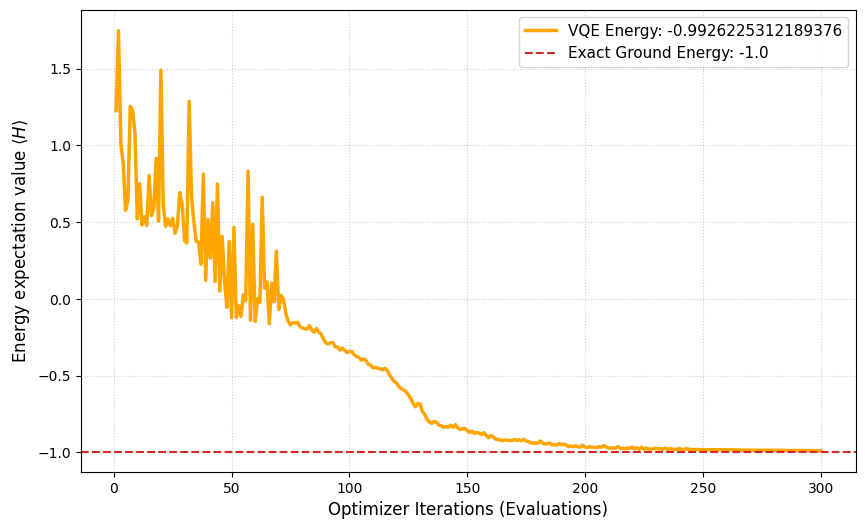

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(counts,values,'-',label='VQE Energy: -0.9926225312189376',color='orange',lw=2.5)
plt.axhline(y=x,color='#d62728',linestyle='--',label='Exact Ground Energy: -1.0')
plt.xlabel('Optimizer Iterations (Evaluations)',fontsize=12)
plt.ylabel('Energy expectation value $\langle H \\rangle$',fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11,loc='upper right')
plt.show()

In [ ]:
x,eigenvector=np.linalg.eigh(qubit_hamil.to_matrix())
actual_wave=eigenvector[:,0]

trialss=ansatz.assign_parameters(RESULT.optimal_parameters)
trial_state=Statevector.from_instruction(trialss)
fidelity=state_fidelity(actual_wave,trial_state)
print(fidelity)

0.9920869559208046
